# Assignment 1: NYC Airbnb Exploratory Data Analysis
**Author:** Muhammad Abbas

## 4.1 Load & Inspect

In this section, we import the required libraries, load the dataset, and inspect its shape and data types.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv('Assignment_Dataset.csv.csv')

# Display the first few rows
display(df.head())

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,32785169,2 Bedroom Refuge with Private Bath & Living Room,20433973,Julia,Bronx,City Island,40.83988,-73.78287,Private room,95,1,6,2019-06-17,1.65,2,359
1,34399984,Two private rooms,259690766,Souadou,Bronx,Belmont,40.85648,-73.88501,Private room,95,2,4,2019-07-01,2.35,1,325
2,36379669,Shared living space in the Bronx!,44378432,Bryan,Bronx,Pelham Bay,40.84735,-73.83095,Shared room,50,1,0,NaN,NaN,1,88
3,35249458,Light-filled comfortable entire apartment,264809787,Kurt,Bronx,Concourse Village,40.82778,-73.91516,Entire home/apt,75,3,2,2019-06-21,2.00,1,253
4,30253236,SedaOn2 Dance Studio,140862407,Angelie,Bronx,Westchester Square,40.84378,-73.84469,Entire home/apt,670,1,2,2019-03-31,0.34,1,178


In [2]:
# Check the shape of the dataset
print(f"Dataset shape: {df.shape}")

# Examine column data types and non-null counts
df.info()

Dataset shape: (4889, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4889 entries, 0 to 4888
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              4889 non-null   int64  
 1   name                            4886 non-null   object 
 2   host_id                         4889 non-null   int64  
 3   host_name                       4889 non-null   object 
 4   neighbourhood_group             4889 non-null   object 
 5   neighbourhood                   4889 non-null   object 
 6   latitude                        4889 non-null   float64
 7   longitude                       4889 non-null   float64
 8   room_type                       4889 non-null   object 
 9   price                           4889 non-null   int64  
 10  minimum_nights                  4889 non-null   int64  
 11  number_of_reviews               4889 non-null   int64  
 12  last_rev

In [3]:
# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Categorical columns: ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']


### Initial Observations (Before Cleaning)
1. **Missing Data:** The columns `name`, `last_review`, and `reviews_per_month` contain missing values (null counts are less than 4889).
2. **Incorrect Data Types:** The `last_review` column contains dates but is currently loaded as an `object` (string) instead of a datetime object.
3. **Dataset Size:** The dataset contains a sample of 4,889 rows and 16 columns.

## 4.2 Data Cleaning

Here we handle missing data, fix data types, and remove unrealistic values.

In [4]:
# Handle missing values

# 1. 'name': Missing names are simply imputed with a placeholder 'Unknown'
df['name'] = df['name'].fillna('Unknown')

# 2. 'reviews_per_month': If there are no reviews, it's safe to assume reviews per month is 0.
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# 3. 'last_review': We convert this to datetime. Missing values will naturally become NaT (Not a Time). 
# We prefer NaT over a fake placeholder date which could skew time-series analysis.
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Verify missing values
print(df.isnull().sum())

id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       1010
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
dtype: int64


### Handling Unrealistic Values
Some values in `price` and `minimum_nights` do not make sense for Airbnb listings. We need to handle these outliers.

In [5]:
# 1. Price: An Airbnb cannot realistically cost $0. We filter out these free listings.
# We consider prices > 0 to be valid.
df = df[df['price'] > 0]

# 2. Minimum Nights: Some listings require an absurd number of minimum nights (e.g., 1000+).
# We cap the minimum_nights at 365 (1 year) since anything above a year operates more like a long-term lease.
df['minimum_nights'] = df['minimum_nights'].clip(upper=365)

print(f"Dataset shape after filtering unrealistic values: {df.shape}")

Dataset shape after filtering unrealistic values: (4885, 16)


### Engineering a New Column
We engineer a new column called `price_category` by binning the price into three equal-sized quantiles: Budget, Mid-Range, and Luxury.

In [6]:
# Engineer a new column based on price quantiles
df['price_category'] = pd.qcut(df['price'], q=3, labels=['Budget', 'Mid-Range', 'Luxury'])
display(df[['price', 'price_category']].head())

,price,price_category
0,95,Mid-Range
1,95,Mid-Range
2,50,Budget
3,75,Budget
4,670,Luxury


## 4.3 Univariate Analysis

We will visualize the distribution of single variables to understand their spread.

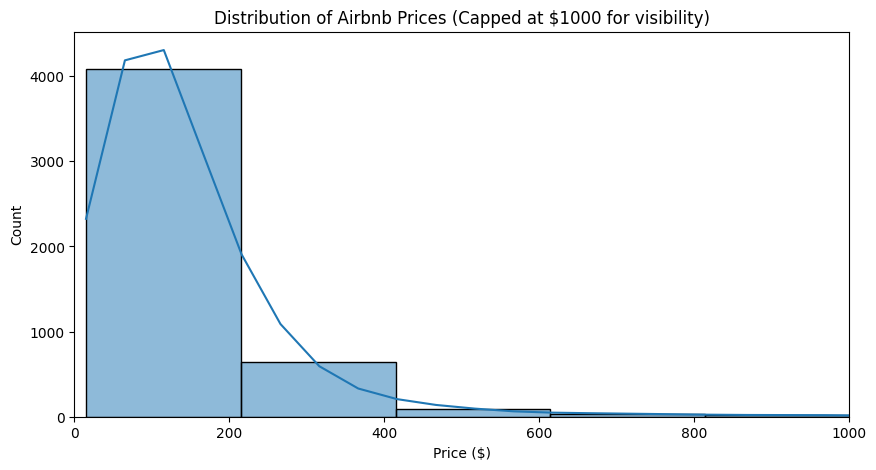

In [7]:
# 1. Distribution of Price
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Airbnb Prices (Capped at $1000 for visibility)')
plt.xlim(0, 1000) # Limiting range because price is heavily right-skewed
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

**Interpretation:** The price is heavily right-skewed. The vast majority of listings cost between $50 and $200 per night. Limiting the x-axis to $1000 makes the bulk of the distribution visible, cutting off extreme luxury outliers.

C:\Users\hp z book\AppData\Local\Temp\ipykernel_12724\3878031889.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='room_type', data=df, order=df['room_type'].value_counts().index, palette='Set2')


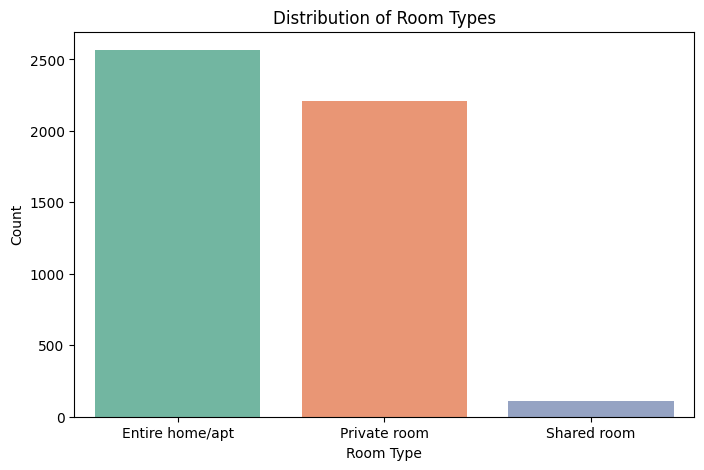

In [8]:
# 2. Distribution of Room Type
plt.figure(figsize=(8, 5))
sns.countplot(x='room_type', data=df, order=df['room_type'].value_counts().index, palette='Set2')
plt.title('Distribution of Room Types')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

**Interpretation:** 'Entire home/apt' and 'Private room' are by far the most common room types. 'Shared room' makes up a very tiny fraction of all available listings.

C:\Users\hp z book\AppData\Local\Temp\ipykernel_12724\3149743275.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='neighbourhood_group', data=df, order=df['neighbourhood_group'].value_counts().index, palette='viridis')


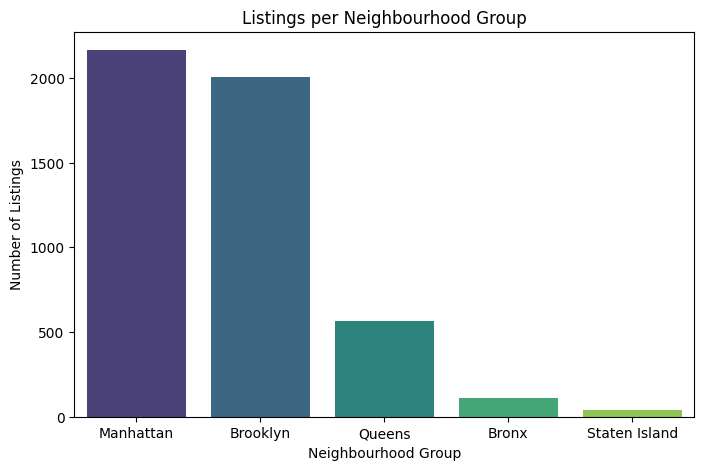

In [9]:
# 3. Distribution of Neighbourhood Group (Borough)
plt.figure(figsize=(8, 5))
sns.countplot(x='neighbourhood_group', data=df, order=df['neighbourhood_group'].value_counts().index, palette='viridis')
plt.title('Listings per Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.show()

**Interpretation:** Manhattan and Brooklyn dominate the Airbnb market in NYC, accounting for the vast majority of listings. Staten Island and Bronx have very few listings comparatively.

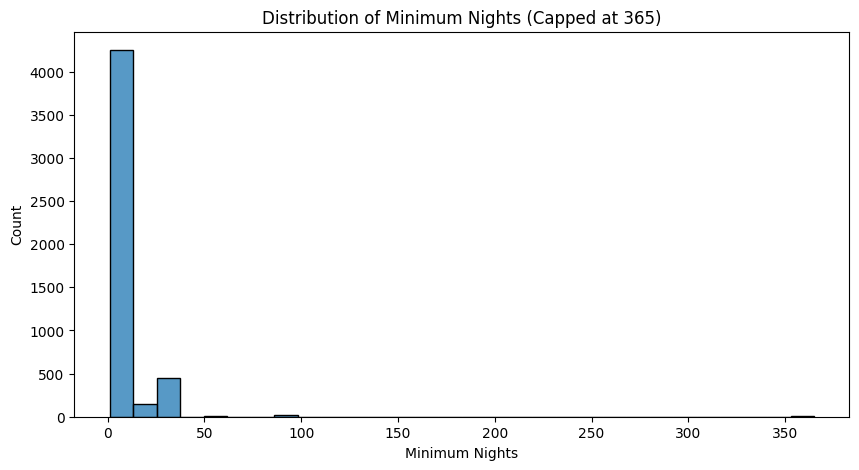

In [10]:
# 4. Distribution of Minimum Nights
plt.figure(figsize=(10, 5))
sns.histplot(df['minimum_nights'], bins=30, kde=False)
plt.title('Distribution of Minimum Nights (Capped at 365)')
plt.xlabel('Minimum Nights')
plt.ylabel('Count')
plt.show()

**Interpretation:** There is a massive spike near 1-3 nights, indicating most hosts cater to short-term stays. However, there is also a noticeable spike around 30 days, reflecting local regulations or hosts preferring monthly rentals.

## 4.4 Bivariate & Multivariate Analysis

We explore the relationships between multiple variables, particularly focusing on what drives the `price`.

C:\Users\hp z book\AppData\Local\Temp\ipykernel_12724\2823863353.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='neighbourhood_group', y='price', data=df, palette='muted')


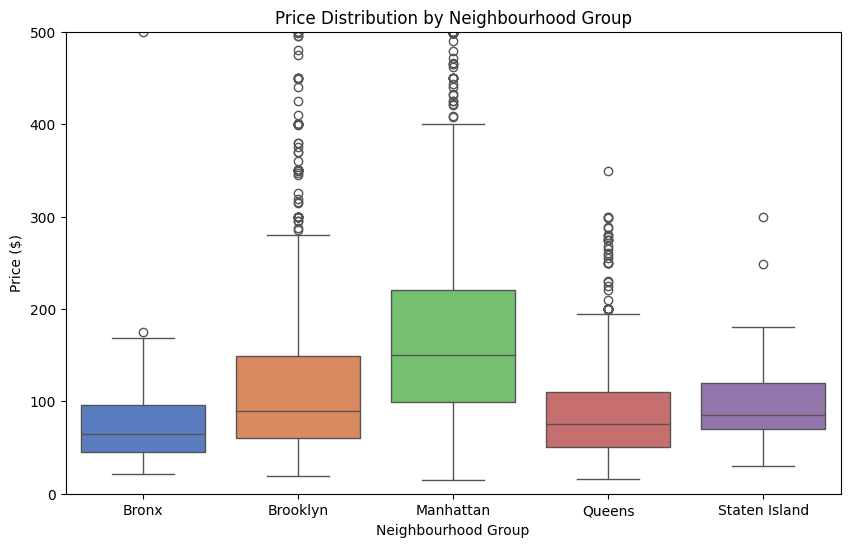

In [11]:
# 1. Price vs Neighbourhood Group
plt.figure(figsize=(10, 6))
sns.boxplot(x='neighbourhood_group', y='price', data=df, palette='muted')
plt.title('Price Distribution by Neighbourhood Group')
plt.ylim(0, 500) # Zooming in to avoid extreme outliers skewing the plot
plt.xlabel('Neighbourhood Group')
plt.ylabel('Price ($)')
plt.show()

**Interpretation:** Manhattan is clearly the most expensive borough on average, with a much higher median price than the others. The Bronx and Staten Island are generally the most affordable.

C:\Users\hp z book\AppData\Local\Temp\ipykernel_12724\1459567594.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='price', data=df, palette='pastel')


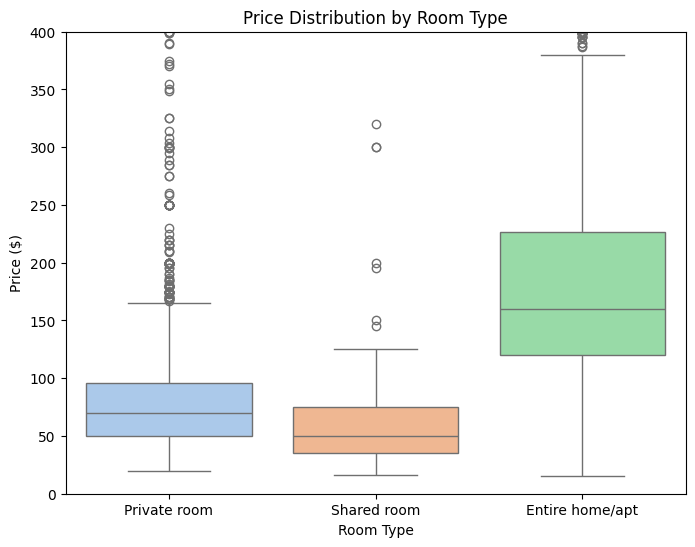

In [12]:
# 2. Price vs Room Type
plt.figure(figsize=(8, 6))
sns.boxplot(x='room_type', y='price', data=df, palette='pastel')
plt.title('Price Distribution by Room Type')
plt.ylim(0, 400)
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.show()

**Interpretation:** 'Entire home/apt' listings command a significant premium over 'Private room' and 'Shared room'. Renting an entire space is substantially more expensive.

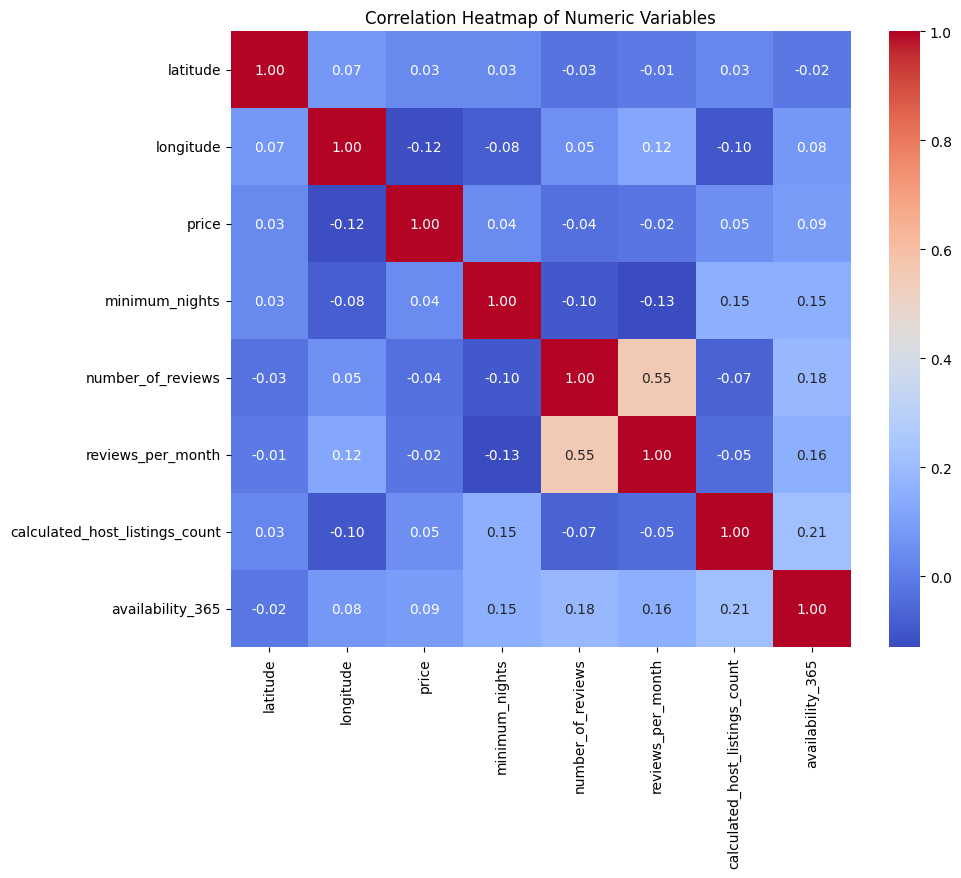

In [13]:
# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number']).drop(columns=['id', 'host_id']) # Drop ID columns as they have no numeric meaning
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

**Interpretation:** Most numeric variables have very weak linear correlations with price. However, `calculated_host_listings_count` and `availability_365` show slight positive correlations, while longitude shows a slight negative correlation (moving west towards Manhattan tends to increase price).

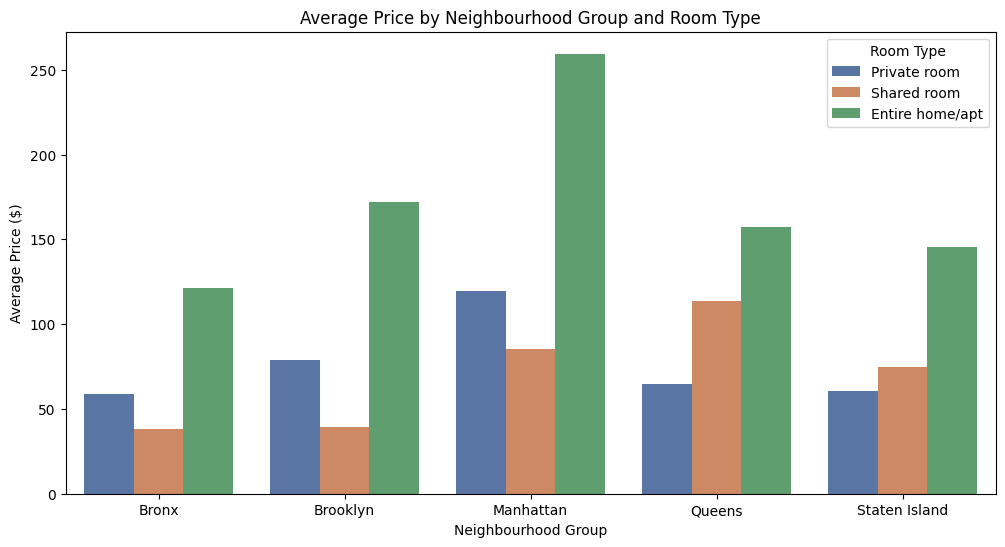

In [14]:
# 4. Three-variable relationship: Average Price by Room Type and Neighbourhood Group
plt.figure(figsize=(12, 6))
sns.barplot(x='neighbourhood_group', y='price', hue='room_type', data=df, errorbar=None, palette='deep')
plt.title('Average Price by Neighbourhood Group and Room Type')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price ($)')
plt.legend(title='Room Type')
plt.show()

**Interpretation:** Across *every single borough*, an 'Entire home/apt' is the most expensive option, followed by 'Private room'. Manhattan's 'Entire home/apt' listings are on average the most expensive combination in the entire dataset.

## 4.5 Summary & Key Insights

Based on our exploratory data analysis, here are the key findings:
1. **Market Concentration:** The NYC Airbnb market is heavily concentrated in **Manhattan** and **Brooklyn**. Finding listings in Staten Island or the Bronx is rare.
2. **Room Preferences:** The vast majority of listings are either **Entire homes/apartments** or **Private rooms**. Shared rooms are almost non-existent.
3. **Price Drivers:** Location and space type are the strongest drivers of price. **Manhattan** is significantly more expensive than other boroughs, and **Entire homes** are significantly more expensive than private rooms.
4. **Minimum Stay Dynamics:** Most listings cater to 1-3 night stays, but there is a clear secondary market for 30+ day rentals, likely due to business travelers or local regulations.

### Actionable Recommendation for a New Host
If you are looking to maximize your nightly revenue and want to start a new listing, **investing in an 'Entire home/apt' in Manhattan** will yield the highest average price. However, if you are on a budget and want to compete in a high-demand area with less initial investment, **offering a 'Private room' in Brooklyn** is a highly popular segment that still draws substantial traffic.